# NB04 - Semi-supervised Pipeline

**PCA fitted on labeled training data + all unlabeled data (per outer fold).**

Only difference from NB03:

```
NB03:  pca.fit(labeled_training_fold)
NB04:  pca.fit(labeled_training_fold + all_unlabeled)  <- only difference
```

PCA never uses labels, so including unlabeled data is valid. The larger sample set gives a more stable estimate of gene co-expression structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "data"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
TABLES_DIR   = REPORTS_DIR / "tables"
for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED        = 42
OUTER_FOLDS = 5
INNER_FOLDS = 3
VAR_THRESH  = 0.01
COLORS      = {"LumA": "#3498db", "LumB": "#2ecc71", "Her2": "#e74c3c", "Basal": "#9b59b6"}
PARAM_GRID  = {"C": [0.01, 0.1, 1.0, 10.0, 100.0], "l1_ratio": [0.1, 0.5, 0.9]}


## Data Loading

In [3]:
def norm_id(sid):
    sid = str(sid).strip()
    return sid[:15] if sid.startswith("TCGA-") and len(sid) >= 15 else sid

expr = pd.read_csv(DATA_DIR / "HiSeqV2.csv", index_col=0)
if any(str(c).startswith("TCGA-") for c in expr.columns[:10]):
    expr = expr.T
expr.index = [norm_id(s) for s in expr.index]
expr = expr.apply(pd.to_numeric, errors="coerce")

pam = pd.read_csv(DATA_DIR / "brca_pam50.csv")
_SC_COLS = ["Sample", "sample", "sample_id", "SampleID", "TCGA_ID", "bcr_patient_barcode"]
_LC_COLS = ["PAM50", "pam50", "Subtype", "subtype", "BRCA_Subtype_PAM50"]
_sc = next((c for c in _SC_COLS if c in pam.columns), pam.columns[0])
_lc = next((c for c in _LC_COLS if c in pam.columns), None)
if _lc is None:
    _lc = next((c for c in pam.columns
                if "pam" in c.lower() or "subtype" in c.lower()), pam.columns[1])
pam = pam[[_sc, _lc]].copy()
pam.columns = ["sample_id", "subtype"]
pam["sample_id"] = pam["sample_id"].apply(norm_id)
pam = pam[pam["subtype"].notna()]
pam = pam[~pam["subtype"].str.lower().isin(["normal", "normal-like", "nan", "unknown"])]
pam = pam.drop_duplicates("sample_id").set_index("sample_id")

common        = expr.index.intersection(pam.index)
labeled_ids   = common.tolist()
unlabeled_ids = [s for s in expr.index if s not in set(labeled_ids)]
X_labeled     = expr.loc[labeled_ids].values.astype(float)
y_labels      = pam.loc[labeled_ids, "subtype"].values
X_unlabeled   = expr.loc[unlabeled_ids].values.astype(float)
GENE_NAMES    = expr.columns.tolist()
CLASSES       = sorted(set(y_labels))
y_arr         = np.array([CLASSES.index(c) for c in y_labels])
print(f"Labeled: {len(labeled_ids)}  Unlabeled: {len(unlabeled_ids)}  Genes: {len(GENE_NAMES):,}")


Labeled: 73  Unlabeled: 1145  Genes: 20,530


In [4]:
with open(TABLES_DIR / "02_n_components.json") as f:
    nc_data = json.load(f)
N_COMPONENTS = nc_data["N_COMPONENTS"]
print(f"N_COMPONENTS = {N_COMPONENTS}  (from 02_n_components.json)")


N_COMPONENTS = 24  (from 02_n_components.json)


## Nested Cross-Validation

In each outer fold, PCA is fit on `labeled_training_fold + ALL unlabeled`. Test set samples are only transformed, never used during fitting.

In [5]:
outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED)

base_clf = LogisticRegression(
    solver="saga",
    class_weight="balanced", max_iter=5000, random_state=SEED,
)

fold_records = []
all_y_true   = []
all_y_pred   = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_labeled, y_arr)):
    X_tr, X_te = X_labeled[train_idx], X_labeled[test_idx]
    y_tr, y_te = y_arr[train_idx], y_arr[test_idx]

    # Combine labeled training fold with ALL unlabeled for PCA basis
    X_pca_basis = np.vstack([X_tr, X_unlabeled])  # ~1,203 samples

    # Preprocessing fit on combined basis (no labels used)
    preproc = Pipeline([
        ("variance", VarianceThreshold(VAR_THRESH)),
        ("scaler",   StandardScaler()),
    ])
    preproc.fit(X_pca_basis)

    # PCA fit on combined basis  <-- semi-supervised
    pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
    pca.fit(preproc.transform(X_pca_basis))

    X_tr_pca = pca.transform(preproc.transform(X_tr))
    X_te_pca = pca.transform(preproc.transform(X_te))

    gs = GridSearchCV(clone(base_clf), PARAM_GRID, cv=inner_cv,
                      scoring="f1_macro", n_jobs=-1)
    gs.fit(X_tr_pca, y_tr)

    y_pred = gs.predict(X_te_pca)
    f1  = f1_score(y_te, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_te, y_pred)

    fold_records.append({
        "fold": fold_i + 1, "f1_macro": round(f1, 4), "accuracy": round(acc, 4),
        "best_C": gs.best_params_["C"], "best_l1": gs.best_params_["l1_ratio"],
        "n_train": len(train_idx), "n_test": len(test_idx),
        "n_pca_basis": X_pca_basis.shape[0],
    })
    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(y_pred.tolist())
    print(f"  Fold {fold_i+1}: F1={f1:.4f}  acc={acc:.4f}  PCA basis={X_pca_basis.shape[0]}")

results_df = pd.DataFrame(fold_records)
print(f"Mean F1: {results_df['f1_macro'].mean():.4f} +/- {results_df['f1_macro'].std():.4f}")


  Fold 1: F1=0.6667  acc=0.6667  PCA basis=1203
  Fold 2: F1=0.6455  acc=0.8000  PCA basis=1203
  Fold 3: F1=0.7367  acc=0.7333  PCA basis=1203
  Fold 4: F1=0.7818  acc=0.7857  PCA basis=1204
  Fold 5: F1=0.7267  acc=0.8571  PCA basis=1204
Mean F1: 0.7115 +/- 0.0552


## Results

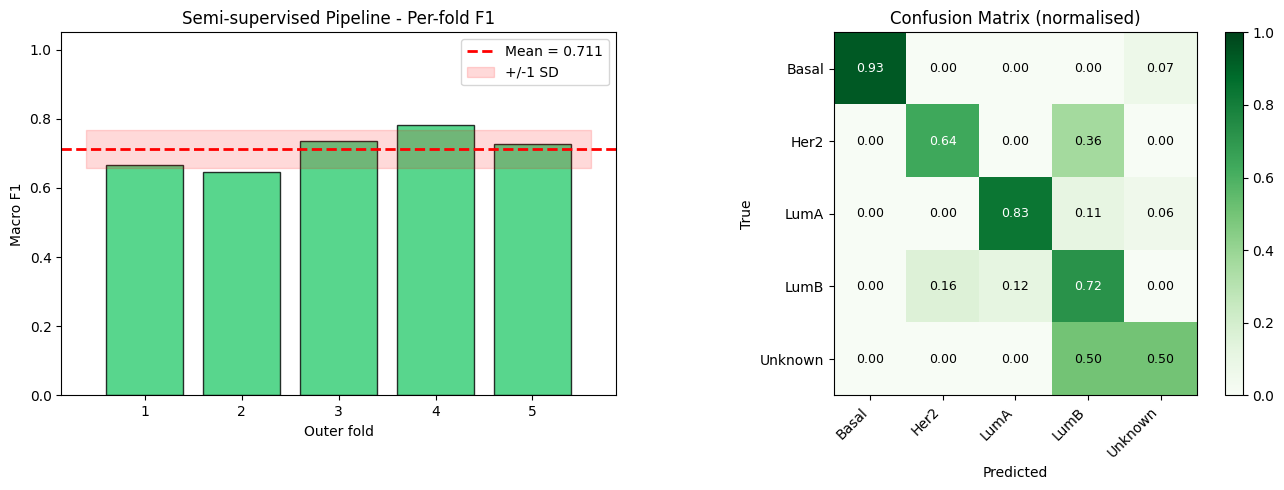

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
mean_f1 = results_df["f1_macro"].mean()
std_f1  = results_df["f1_macro"].std()
ax.bar(results_df["fold"], results_df["f1_macro"],
       color="#2ecc71", edgecolor="black", alpha=0.8)
ax.axhline(mean_f1, color="red", linestyle="--", lw=2, label=f"Mean = {mean_f1:.3f}")
ax.fill_between([0.4, OUTER_FOLDS + 0.6], mean_f1 - std_f1, mean_f1 + std_f1,
                color="red", alpha=0.15, label="+/-1 SD")
ax.set_xlabel("Outer fold")
ax.set_ylabel("Macro F1")
ax.set_title("Semi-supervised Pipeline - Per-fold F1")
ax.set_ylim(0, 1.05)
ax.legend()

cm      = confusion_matrix(all_y_true, all_y_pred, labels=list(range(len(CLASSES))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ax = axes[1]
im = ax.imshow(cm_norm, cmap="Greens", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (normalised)")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if cm_norm[i,j] > 0.6 else "black")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_ssl_results.png", dpi=150, bbox_inches="tight")
plt.show()


## Save

In [7]:
results_df.to_csv(TABLES_DIR / "04_ssl_cv_results.csv", index=False)

summary = {
    "pipeline":      "semisupervised",
    "pca_fit_on":    "labeled_training_fold_plus_all_unlabeled",
    "N_COMPONENTS":  int(N_COMPONENTS),
    "OUTER_FOLDS":   OUTER_FOLDS,
    "INNER_FOLDS":   INNER_FOLDS,
    "VAR_THRESH":    VAR_THRESH,
    "f1_macro_mean": round(results_df["f1_macro"].mean(), 4),
    "f1_macro_std":  round(results_df["f1_macro"].std(), 4),
    "accuracy_mean": round(results_df["accuracy"].mean(), 4),
    "per_class_f1":  {c: round(f1_score(all_y_true, all_y_pred,
                         labels=[CLASSES.index(c)], average="macro",
                         zero_division=0), 4) for c in CLASSES},
}
with open(TABLES_DIR / "04_ssl_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: 04_ssl_summary.json  +  04_ssl_cv_results.csv")
print(json.dumps(summary, indent=2))


Saved: 04_ssl_summary.json  +  04_ssl_cv_results.csv
{
  "pipeline": "semisupervised",
  "pca_fit_on": "labeled_training_fold_plus_all_unlabeled",
  "N_COMPONENTS": 24,
  "OUTER_FOLDS": 5,
  "INNER_FOLDS": 3,
  "VAR_THRESH": 0.01,
  "f1_macro_mean": 0.7115,
  "f1_macro_std": 0.0552,
  "accuracy_mean": 0.7686,
  "per_class_f1": {
    "Basal": 0.9655,
    "Her2": 0.6364,
    "LumA": 0.8333,
    "LumB": 0.7059,
    "Unknown": 0.5
  }
}
